In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
print(os.listdir('/content/drive/MyDrive/'))


Mounted at /content/drive
['Mine', 'Colab Notebooks', 'petclass.zip']


In [4]:
import zipfile

with zipfile.ZipFile(
    '/content/drive/MyDrive/petclass.zip',
    'r') as zip_ref:
    zip_ref.extractall('/content/PetImages')

print("done!")
os.listdir('/content/PetImages')

done!


['PetImages']

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],
                         [0.5,0.5,0.5])
])

dataset = datasets.ImageFolder(
    root='/content/PetImages/PetImages',
    transform=transform
)

train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("classes:", dataset.classes)
print("training images:", len(train_dataset))
print("testing images:",  len(test_dataset))

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 128, 3)
        self.fc1   = nn.Linear(128*14*14, 128)
        self.fc2   = nn.Linear(128, 64)
        self.fc3   = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model     = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    loss_item = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        loss   = criterion(output, labels)
        loss.backward()
        optimizer.step()
        loss_item += loss.item()

    avg_loss = loss_item / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

model.eval()
correct = 0
total   = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

torch.save(model.state_dict(), "cat_dog_cnn.pth")
print("model saved!")

using device: cuda
classes: ['Cat', 'Dog']
training images: 19998
testing images: 5000


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/10] Loss: 0.5719


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [2/10] Loss: 0.4197


...

Epoch [8/10] Loss: 0.0363


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [9/10] Loss: 0.0369


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [10/10] Loss: 0.0274
Test Accuracy: 83.58%
model saved!


upload a cat or dog image!


Saving 6.jpg to 6.jpg


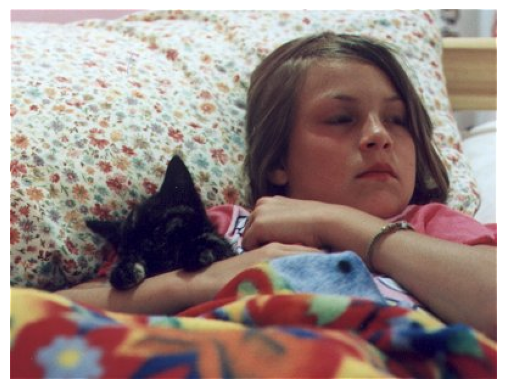

Prediction : Cat
Confidence : 100.00%


In [9]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

print("upload a cat or dog image!")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
image    = Image.open(filename).convert("RGB")

plt.imshow(image)
plt.axis('off')
plt.show()

transform_pred = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

img_tensor = transform_pred(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output    = model(img_tensor)
    _, predicted = torch.max(output, 1)

    classes    = ['Cat', 'Dog']  # ← hardcoded!
    result     = classes[predicted.item()]

    probs      = torch.softmax(output, dim=1)
    confidence = probs[0][predicted.item()].item() * 100

print(f"Prediction : {result}")
print(f"Confidence : {confidence:.2f}%")

In [11]:
]

Cloning into 'Machine_Learning'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 127 (delta 0), reused 1 (delta 0), pack-reused 124 (from 1)
Receiving objects: 100% (127/127), 45.94 MiB | 25.57 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/Machine_Learning


FileNotFoundError: [Errno 2] No such file or directory: '/content/cat_dog_cnn.py'

In [16]:
import os
print(os.listdir('/content/drive/MyDrive/'))
# find your notebook name here!

['Mine', 'Colab Notebooks', 'petclass.zip', 'catvsdog.ipynb']


In [17]:
import os
import shutil

# create convolution folder
os.makedirs('convolution', exist_ok=True)

# copy notebook from drive
# replace with your exact notebook name!
shutil.copy(
    '/content/drive/MyDrive/catvsdog.ipynb',
    'convolution/cat_dog_cnn.ipynb'
)

# copy trained model
shutil.copy(
    '/content/cat_dog_cnn.pth',
    'convolution/cat_dog_cnn.pth'
)

print("files copied!")
print(os.listdir('convolution/'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/cat_dog_cnn.ipynb'